In [127]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [30]:
plt.rcParams['font.sans-serif'] = 'Roboto'   # Specific font name
plt.rcParams['font.size'] = 12              # Default text size in points
plt.rcParams['font.style'] = 'normal'       # Options: normal, italic, oblique
plt.rcParams['font.weight'] = 'normal'      # Options: normal, bold, etc.
plt.rcParams["lines.linewidth"] = 3.0  # Set global default line width

In [31]:
df = pd.read_csv("../datasets/sales_data_cln.csv").copy()

In [32]:
df.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'refund_ts',
       'product_name', 'product_id', 'usd_price', 'purchase_platform',
       'marketing_channel', 'account_creation_method', 'country_code',
       'purchase_y', 'purchase_ym', 'purchase_ymd', 'purchase_ymw',
       'purchase_q', 'ship_y', 'ship_ym', 'ship_ymd', 'ship_ymw', 'ship_q'],
      dtype='object')

In [33]:
# co: completed_orders
co = df[df["refund_ts"].isna()]

In [34]:
# Generate revenue data
rev_data_ym = co.groupby("purchase_ym").agg(total_revenue=("usd_price", "sum"), total_orders = ("order_id", "count")).reset_index()

In [130]:
rev_data_ym["purchase_ym"] = pd.to_datetime(rev_data_ym["purchase_ym"], format="%Y-%m")

In [113]:
rev_data_ym["ym_aov"] = (rev_data_ym["total_revenue"] / rev_data_ym["total_orders"]).round(2)
lowest_rev = rev_data_ym["total_revenue"].min()
highest_rev = rev_data_ym["total_revenue"].max()

low_rev = rev_data_ym.nsmallest(5, columns='total_revenue')
high_rev = rev_data_ym.nlargest(3, columns='total_revenue')


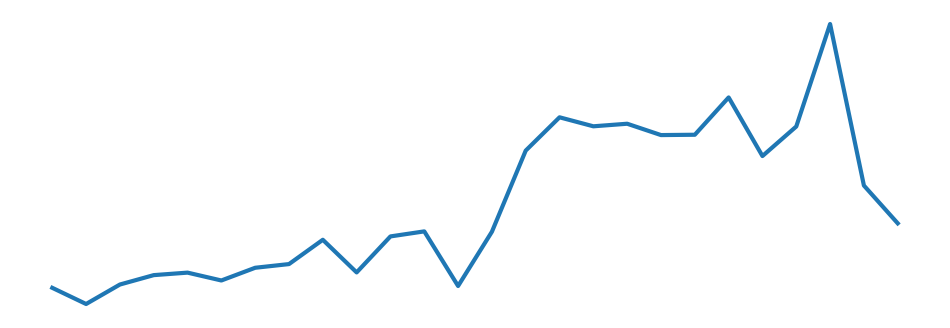

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

ax.plot(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"])
# ax.scatter(rev_data_ym["order_year_month"], rev_data_ym["gross_margin"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])

# ax.set_title("GROSS MARGIN PER MONTH")
plt.show()

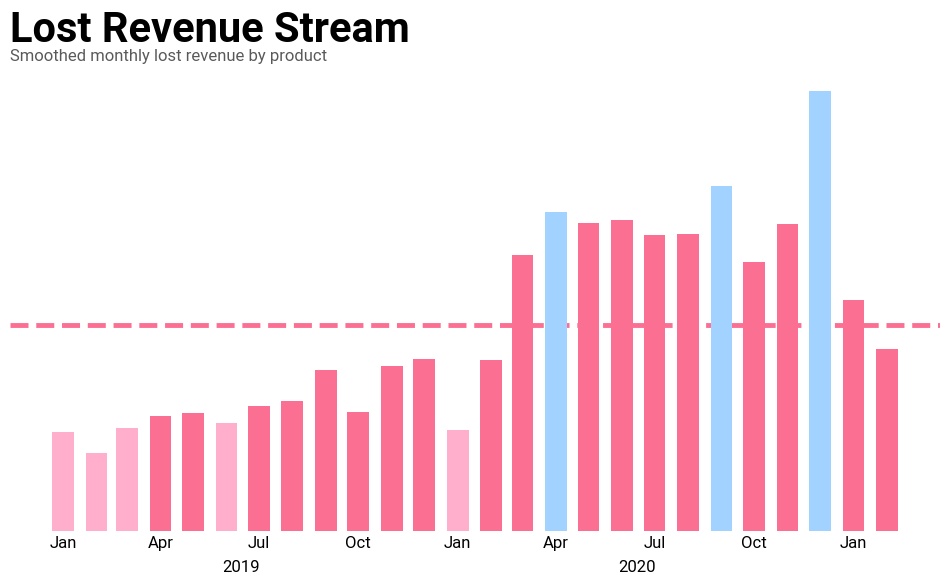

In [210]:
fig, ax = plt.subplots(figsize=(12, 6))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')


ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"], width = 20, color = "#fb6f92")
ax.bar(low_rev["purchase_ym"], low_rev["total_revenue"], width = 20, color = "#ffafcc")
ax.bar(high_rev["purchase_ym"], high_rev["total_revenue"], width = 20, color = "#a2d2ff")
ax.axhline(y=rev_data_ym["total_revenue"].mean(), color="#fb6f92", linestyle='--', linewidth=3.5, zorder=0)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
# ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
# ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])




#####
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# years (major ticks), placed mid-year so they don't collide with Jan/Jul
ax.xaxis.set_major_locator(mdates.YearLocator(month=6, day=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.tick_params(axis="x", which="major", pad=20, length=0)
ax.tick_params(axis="x", which="minor", pad=3, length=0)

####

# Title
ax.set_title(
    "Lost Revenue Stream",
    fontsize=30,
    fontweight="bold",
    loc="left",
    pad=20
)

# Subtitle
ax.text(
    0,
    1.02,
    "Smoothed monthly lost revenue by product",
    transform=ax.transAxes,
    fontsize=12,
    alpha=0.65
)


# Annotations
plt.annotate(
    "$400k", 
    xy=(23, 390000),          # Arrow tip points here
    xytext=(18.5, 410000),     # Text box goes here
    arrowprops=dict(
        facecolor='black', # Arrow color
        arrowstyle='->',   # Simple arrow style (e.g., '->', '<->', 'wedge')
        lw=2            # Line width
    )
)

plt.savefig("../figures/executive_summary/executive_summary.png", transparent=True, dpi=300)

plt.show()

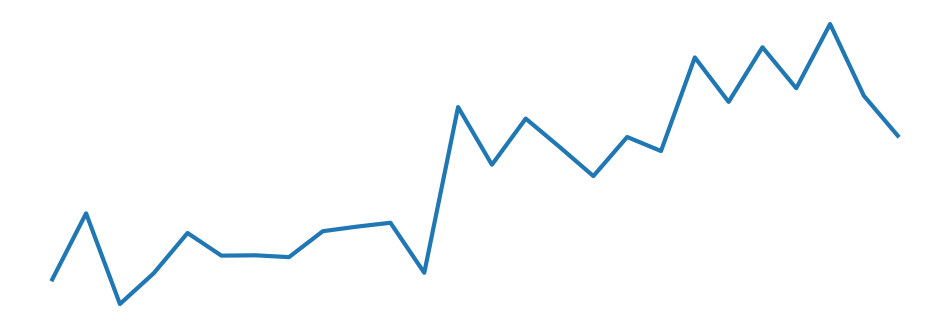

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

ax.plot(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])

# ax.set_title("GROSS MARGIN PER MONTH")
plt.show()

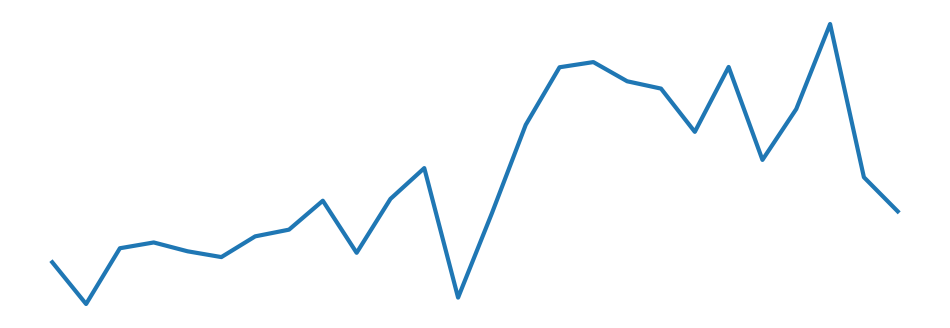

In [39]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(rev_data_ym["purchase_ym"], rev_data_ym["total_orders"])

# ax.plot(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])

# ax.set_title("GROSS MARGIN PER MONTH")
plt.show()

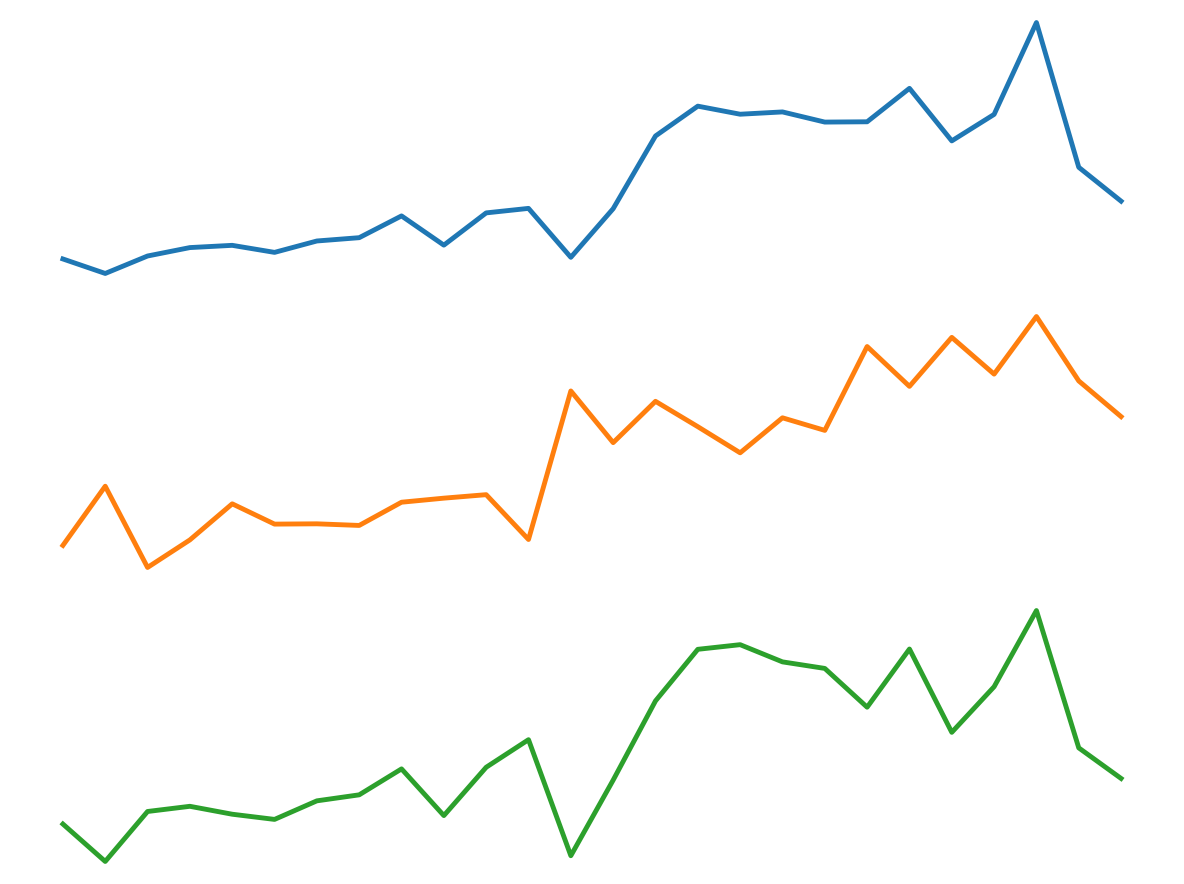

In [40]:
# Create 3 stacked subplots sharing the x-axis
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(12, 9))

# Plot data on each axis
# ax[0].axhline(y=rev_data_ym["total_revenue"].mean(), color='red', linestyle='--', linewidth=1)
ax[0].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_revenue"], color='tab:blue', linewidth=3.5)
ax[0].set_ylabel('total_revenue')
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["left"].set_visible(False)
ax[0].spines["bottom"].set_visible(False)
ax[0].axes.get_xaxis().set_visible(False)
ax[0].axes.get_yaxis().set_visible(False)


# ax[1].axhline(y=rev_data_ym["ym_aov"].mean(), color='red', linestyle='--', linewidth=1)
ax[1].plot(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov"], color='tab:orange', linewidth=3.5)
ax[1].set_ylabel('aov')
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["left"].set_visible(False)
ax[1].spines["bottom"].set_visible(False)
ax[1].axes.get_xaxis().set_visible(False)
ax[1].axes.get_yaxis().set_visible(False)


# ax[2].axhline(y=rev_data_ym["total_orders"].mean(), color='red', linestyle='--', linewidth=1)
ax[2].plot(rev_data_ym["purchase_ym"], rev_data_ym["total_orders"], color='tab:green', linewidth=3.5)
ax[2].set_ylabel('total_orders')
ax[2].spines["top"].set_visible(False)
ax[2].spines["right"].set_visible(False)
ax[2].spines["left"].set_visible(False)
ax[2].spines["bottom"].set_visible(False)
ax[2].axes.get_xaxis().set_visible(False)
ax[2].axes.get_yaxis().set_visible(False)

# Set the x-label on the bottom plot only
# ax[2].set_xlabel('X Axis')


fig.subplots_adjust(hspace=0)
# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig("../figures/sales/sales.png", transparent=True, dpi=300)
plt.show()

In [41]:
rev_data_ym["total_rev_growth_pct"] = (100.0 * (rev_data_ym["total_revenue"] - rev_data_ym["total_revenue"].shift(1))/rev_data_ym["total_revenue"]).round(1)
rev_data_ym["total_orders_growth_pct"] = (100.0 * (rev_data_ym["total_orders"] - rev_data_ym["total_orders"].shift(1))/rev_data_ym["total_orders"]).round(1)
rev_data_ym["ym_aov_growth_pct"] = (100.0 * (rev_data_ym["ym_aov"] - rev_data_ym["ym_aov"].shift(1))/rev_data_ym["ym_aov"]).round(1)
rev_data_ym

,purchase_ym,total_revenue,total_orders,ym_aov,total_rev_growth_pct,total_orders_growth_pct,ym_aov_growth_pct
0,2019-01,91802.39,435,211.04,NaN,NaN,NaN
1,2019-02,72440.62,298,243.09,-26.7,-46.0,13.2
2,2019-03,95762.11,481,199.09,24.4,38.0,-22.1
3,2019-04,107012.02,500,214.02,10.5,3.8,7.0
4,2019-05,110005.20,471,233.56,2.7,-6.2,8.4
5,2019-06,100603.50,452,222.57,-9.3,-4.2,-4.9
6,2019-07,115821.61,520,222.73,13.1,13.1,0.1
7,2019-08,120240.82,542,221.85,3.7,4.1,-0.4
8,2019-09,149331.91,637,234.43,19.5,14.9,5.4
9,2019-10,110267.37,466,236.63,-35.4,-36.7,0.9


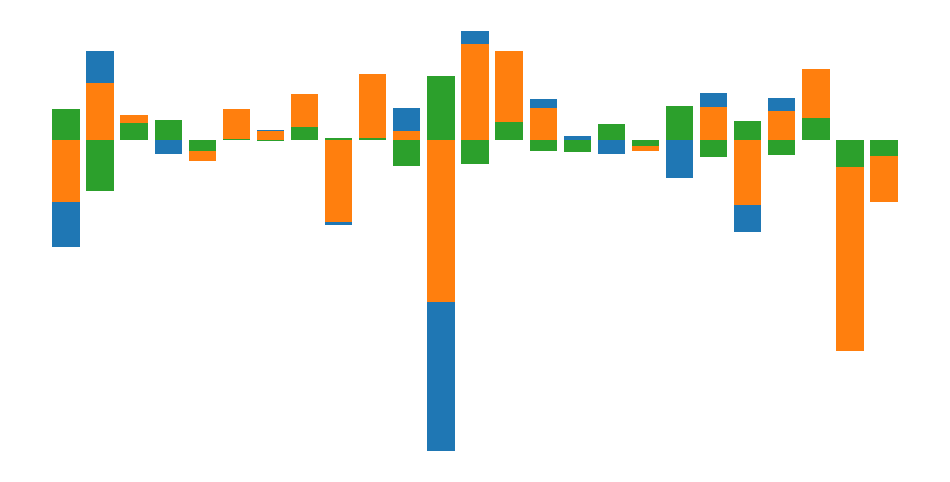

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_orders_growth_pct"])
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["total_rev_growth_pct"])
ax.bar(rev_data_ym["purchase_ym"], rev_data_ym["ym_aov_growth_pct"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])

# ax.set_title("GROSS MARGIN PER MONTH")
plt.savefig("../figures/sales/rev_orders.png", transparent=True, dpi=300)

plt.show()